<a href="https://colab.research.google.com/github/potgieterphiline/MBDS/blob/main/MIT801_SL_Q1_Exam_Philine_Potgieter_u27043275.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

#Question 1a)

In [13]:
log_data = pd.read_excel('/content/sample_data/LogData .xlsx')
print(log_data.head())

         x  TT
0   84.898   0
1   47.335   1
2   21.867   0
3  138.166   1
4  113.358   1


In [24]:
X = log_data[['x']]
y = log_data['TT']

model = LogisticRegression()
model.fit(X, y)

beta_0 = model.intercept_[0]
beta_1 = model.coef_[0]

print("Intercept (beta_0):", beta_0)
print("Coefficient(s) (beta_1):", beta_1)

# Linear predictor η(x) = beta_0 + beta_1 * x
eta = beta_0 + np.dot(X, beta_1)


Intercept (beta_0): -1.949633370214737
Coefficient(s) (beta_1): [0.02429115]


In [26]:
probabilities = model.predict_proba(X)
p_tt_eq_1 = probabilities[:, 1]


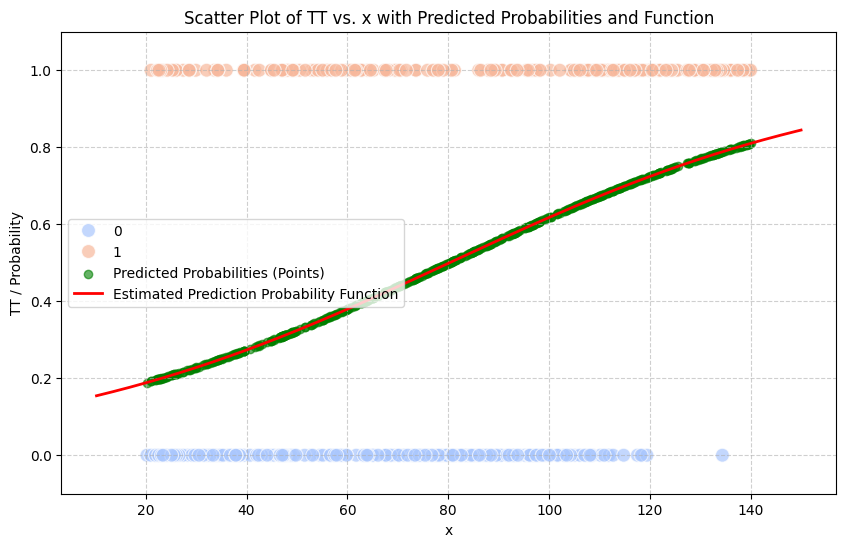

In [27]:
# scatter plot - actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=log_data['x'], y=log_data['TT'], hue=log_data['TT'], palette='coolwarm', s=100, alpha=0.7, legend='full')

# Plot the predicted probabilities
plt.scatter(log_data['x'], p_tt_eq_1, color='green', label='Predicted Probabilities (Points)', alpha=0.6)

# estimated prediction probability
x_range = np.linspace(log_data['x'].min() - 10, log_data['x'].max() + 10, 300)

#corresponding probabilities:sigmoid function
sigmoid_curve = 1 / (1 + np.exp(-(beta_0 + beta_1[0] * x_range)))
plt.plot(x_range, sigmoid_curve, color='red', linewidth=2, label='Estimated Prediction Probability Function')

plt.title('Scatter Plot of TT vs. x with Predicted Probabilities and Function')
plt.xlabel('x')
plt.ylabel('TT / Probability')
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [28]:
# Somers' D: AUC-ROC by the formula D = 2 * AUC - 1
auc_score = roc_auc_score(y, p_tt_eq_1)
somers_d = 2 * auc_score - 1

print(f"\nAUC Score: {auc_score:.4f}")
print(f"Somers' D: {somers_d:.4f}")


AUC Score: 0.7227
Somers' D: 0.4453


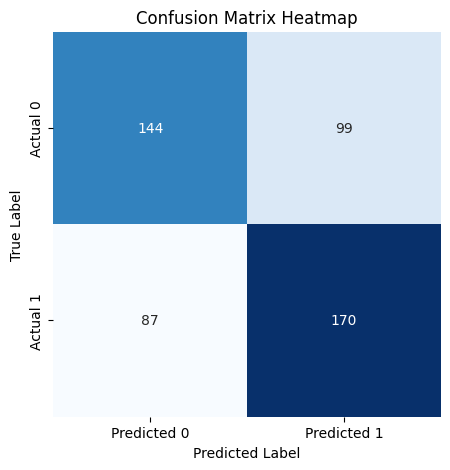

In [29]:
y_pred_class = (p_tt_eq_1 >= 0.5).astype(int)

conf_matrix = confusion_matrix(y, y_pred_class)

plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Question 1b)

In [30]:
knots = [50, 80]
X_transformed = pd.DataFrame({'x': X['x']})

# polynomial terms
X_transformed['x_sq'] = X['x']**2
X_transformed['x_cub'] = X['x']**3

# functions for each knot
for k in knots:
    X_transformed[f'x_knot_{k}'] = np.where(X['x'] > k, (X['x'] - k)**3, 0)

print("Transformed features (first 5 rows):")
print(X_transformed.head())

# pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='liblinear'))
])

pipeline.fit(X_transformed, y)

# coefficient estimates
beta_0_spline = pipeline.named_steps['logreg'].intercept_[0]
beta_spline = pipeline.named_steps['logreg'].coef_[0]

print(f"Intercept (beta_0): {beta_0_spline:.4f}")
print("Coefficient(s) for basis functions:")
for i, col in enumerate(X_transformed.columns):
    print(f"  {col}: {beta_spline[i]:.4f}")

Transformed features (first 5 rows):
         x          x_sq         x_cub      x_knot_50      x_knot_80
0   84.898   7207.670404  6.119168e+05   42501.241359     117.504999
1   47.335   2240.602225  1.060589e+05       0.000000       0.000000
2   21.867    478.165689  1.045605e+04       0.000000       0.000000
3  138.166  19089.843556  2.637567e+06  685335.791358  196792.071318
4  113.358  12850.036164  1.456654e+06  254333.974879   37119.320119
Intercept (beta_0): 0.5258
Coefficient(s) for basis functions:
  x: -0.0501
  x_sq: -0.4571
  x_cub: -0.0688
  x_knot_50: 1.3246
  x_knot_80: 1.2767


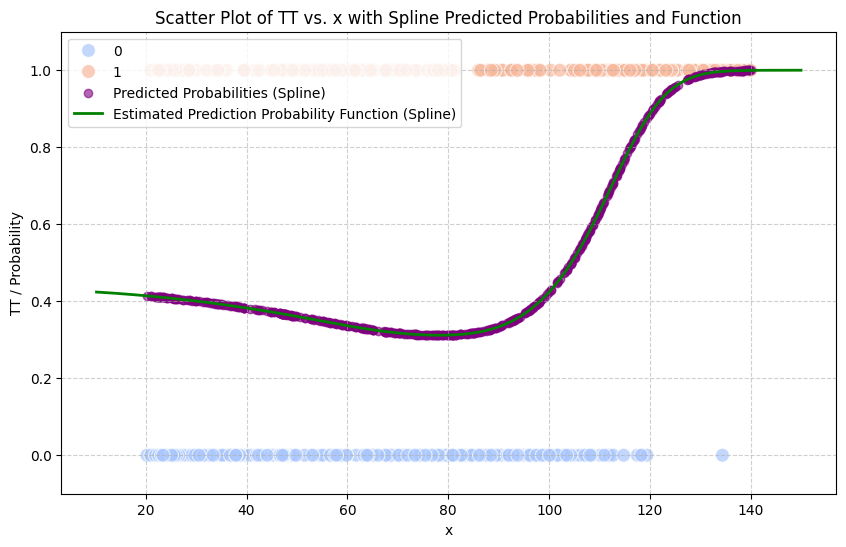

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=log_data['x'], y=log_data['TT'], hue=log_data['TT'], palette='coolwarm', s=100, alpha=0.7, legend='full')

# Predict probabilities for the original data points
p_tt_eq_1_spline_predicted = pipeline.predict_proba(X_transformed)[:, 1]

# redicted probabilities from the spline model
plt.scatter(log_data['x'], p_tt_eq_1_spline_predicted, color='purple', label='Predicted Probabilities (Spline)', alpha=0.6)

# Generate x values
x_range_spline = np.linspace(X['x'].min() - 10, X['x'].max() + 10, 500).reshape(-1, 1)

x_range_transformed = pd.DataFrame({'x': x_range_spline.flatten()})
x_range_transformed['x_sq'] = x_range_spline**2
x_range_transformed['x_cub'] = x_range_spline**3

for k in knots:
    x_range_transformed[f'x_knot_{k}'] = np.where(x_range_spline > k, (x_range_spline - k)**3, 0)

# Predict probabilities for the smooth curve using the fitted pipeline
p_tt_eq_1_spline = pipeline.predict_proba(x_range_transformed)[:, 1]

# Plot the estimated prediction probability function (spline sigmoid curve)
plt.plot(x_range_spline, p_tt_eq_1_spline, color='green', linewidth=2, label='Estimated Prediction Probability Function (Spline)')

plt.title('Scatter Plot of TT vs. x with Spline Predicted Probabilities and Function')
plt.xlabel('x')
plt.ylabel('TT / Probability')
plt.ylim(-0.1, 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

Confusion Matrix for Spline Model:
[[223  20]
 [114 143]]

AUC Score for Spline Model: 0.7617
Somers' D for Spline Model: 0.5234


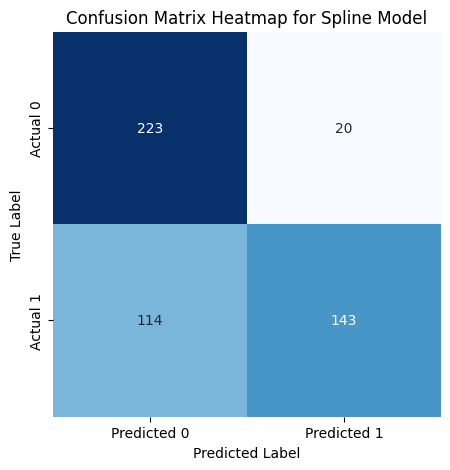

In [33]:
y_pred_class_spline = (p_tt_eq_1_spline_predicted >= 0.5).astype(int)

# Confusion Matrix
conf_matrix_spline = confusion_matrix(y, y_pred_class_spline)
print("Confusion Matrix for Spline Model:")
print(conf_matrix_spline)

# CAUC Score and Somers' D
auc_score_spline = roc_auc_score(y, p_tt_eq_1_spline_predicted)
somers_d_spline = 2 * auc_score_spline - 1

print(f"\nAUC Score for Spline Model: {auc_score_spline:.4f}")
print(f"Somers' D for Spline Model: {somers_d_spline:.4f}")

# Visualize the Confusion Matrix for spline model
plt.figure(figsize=(5, 5))
sns.heatmap(conf_matrix_spline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap for Spline Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#Question 1c)

In [34]:
def calculate_confusion_matrix_metrics(conf_matrix):
    TN, FP, FN, TP = conf_matrix.ravel()
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "Specificity": specificity, "F1-Score": f1_score}

# Metrics for Initial Model
initial_model_metrics = calculate_confusion_matrix_metrics(conf_matrix)
initial_model_metrics["AUC"] = auc_score
initial_model_metrics["Somers' D"] = somers_d

# Metrics for Spline Model
spline_model_metrics = calculate_confusion_matrix_metrics(conf_matrix_spline)
spline_model_metrics["AUC"] = auc_score_spline
spline_model_metrics["Somers' D"] = somers_d_spline

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Logtistic Regression Model (LRM)': initial_model_metrics,
    'Logtistic Regression Cubic Splines Model (LRSM)': spline_model_metrics
}).T # Transpose to have models as rows

print("\n--- Model Comparison Table ---\n")

# Make the table prettier using pandas styling
styled_comparison_df = comparison_df.style.format('{:.4f}')\
                                      .background_gradient(cmap='Blues', subset=pd.IndexSlice[:, ['AUC', "Somers' D"]])\
                                      .highlight_max(axis=0, subset=pd.IndexSlice[:, ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score', 'AUC', "Somers' D"]], props='font-weight: bold; background-color: #aaffaa; color: black;')\
                                      .set_properties(**{'border-color': '#cccccc', 'border-style': 'solid', 'border-width': '1px'})

display(styled_comparison_df)



--- Model Comparison Table ---



,Accuracy,Precision,Recall,Specificity,F1-Score,AUC,Somers' D
Logtistic Regression Model (LRM),0.6280,0.6320,0.6615,0.5926,0.6464,0.7227,0.4453
Logtistic Regression Cubic Splines Model (LRSM),0.7320,0.8773,0.5564,0.9177,0.6810,0.7617,0.5234
